In [3]:
!nvidia-smi

Sat Aug  1 15:31:56 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 591.66                 Driver Version: 591.66         CUDA Version: 13.1     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 4050 ...  WDDM  |   00000000:01:00.0  On |                  N/A |
| N/A   36C    P8              1W /  105W |     875MiB /   6141MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [42]:
!git clone https://github.com/Omid-Nejati/Locality-iN-Locality.git

Cloning into 'Locality-iN-Locality'...


In [5]:
cd /Locality-iN-Locality

[WinError 2] The system cannot find the file specified: '/Locality-iN-Locality'
D:\Projects\MachineLearning\Locality-iN-Locality


In [6]:
pip install torchattacks

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [7]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

import torch
import torch.nn as nn
import torch.optim as optim

import torchvision.utils
import torchvision.transforms as transforms

import torchattacks
from torchattacks import PGD, FGSM

In [8]:
print("PyTorch", torch.__version__)
print("Torchvision", torchvision.__version__)
print("Torchattacks", torchattacks.__version__)
print("Numpy", np.__version__)

PyTorch 2.13.0+cu126
Torchvision 0.28.0+cu126
Torchattacks 3.5.1
Numpy 2.5.1


## GTSRB

In [9]:
!mkdir data

!curl --url https://sid.erda.dk/public/archives/daaeac0d7ce1152aea9b61d9f1e19370/GTSRB_Final_Training_Images.zip -o data/GTSRB_Final_Training_Images.zip
!curl --url https://sid.erda.dk/public/archives/daaeac0d7ce1152aea9b61d9f1e19370/GTSRB_Final_Test_Images.zip -o data/GTSRB_Final_Test_Images.zip
!curl --url https://sid.erda.dk/public/archives/daaeac0d7ce1152aea9b61d9f1e19370/GTSRB_Final_Test_GT.zip -o data/GTSRB_Final_Test_GT.zip

A subdirectory or file data already exists.


^C


  % Total    % Received % Xferd  Average Speed  Time    Time    Time   Current
                                 Dload  Upload  Total   Spent   Left   Speed

  0      0   0      0   0      0      0      0           00:01              0
  0 263.4M   0 109.1k   0      0  42409      0 1:48:35   00:02 1:48:33  91208
  0 263.4M   0 655.9k   0      0 169.8k      0   26:28   00:03   26:25 267.5k
  0 263.4M   0  1.23M   0      0 248.1k      0   18:07   00:05   18:02 342.9k
  0 263.4M   0  1.79M   0      0 291.9k      0   15:24   00:06   15:18 375.8k
  1 263.4M   1  2.72M   0      0 380.1k      0   11:49   00:07   11:42 470.6k
  1 263.4M   1  3.93M   0      0 482.4k      0   09:19   00:08   09:11 685.4k
  1 263.4M   1  4.74M   0      0 517.9k      0   08:40   00:09   08:31 761.4k
  2 263.4M   2  5.67M   0      0 558.6k      0   08:02   00:10   07:52 857.0k
  2 263.4M   2  6.88M   0      0 617.3k      0   07:17   00:11   07:06  0.99M
  2 263.4M   2  7.30M   0      0 594.0k      0   07:34   00:12 

In [10]:
!unzip -o data/GTSRB_Final_Training_Images.zip -d data/ > /dev/null 2>&1
!unzip -o data/GTSRB_Final_Test_Images.zip -d data/ > /dev/null 2>&1
!unzip -o data/GTSRB_Final_Test_GT.zip -d data/

The system cannot find the path specified.
The system cannot find the path specified.
'unzip' is not recognized as an internal or external command,
operable program or batch file.


In [11]:
import shutil

In [12]:
data_dir = './data/GTSRB'
images_dir = os.path.join(data_dir, 'Final_Test/Images')

test_dir = os.path.join(data_dir, 'test')
os.makedirs(test_dir, exist_ok=True)



with open('./data/GT-final_test.csv') as f:
  image_names = f.readlines()

for text in image_names[1:]:
  classes = int(text.split(';')[-1])
  image_name = text.split(';')[0]


  test_class_dir = os.path.join(test_dir, f"{classes:04d}")
  os.makedirs(test_class_dir, exist_ok=True)
  image_path = os.path.join(images_dir, image_name)

  shutil.copy(image_path, test_class_dir)

In [13]:
# ---------------------------------------------------------------------------
# Training augmentation, ported from train_local.py's gpu_augment().
#
# The original block (kept below, still commented) was dead code: `transform_list`
# is built and then never referenced by `trainset`. It is also not GTSRB-safe.
# Verdict on each original line:
#
#   miror = RandomHorizontalFlip(p=0.7)
#       DROPPED. Several GTSRB classes are mirror images of one another
#       (turn-left vs turn-right; the two 'dangerous curve' signs). A flip
#       relabels the image, so this puts a hard ceiling on accuracy no matter
#       how long you train. This is the single most damaging line in the block.
#
#   Randomcrop = RandomApply([RandomResizedCrop(100)], p=0.7)
#       DROPPED. Emits 100x100. The model is built with img_size=224 and
#       patch_size=16, so its positional embeddings require exactly 224 --
#       this raises a shape error, it does not merely degrade accuracy.
#
#   GaussianBlur((3,7), sigma=5)
#       DROPPED. sigma=5 on a 224px sign erases the glyph, not just fine
#       texture, producing training images with no recoverable label.
#
#   Perspective = RandomPerspective(0.5, p=0.7)
#       DROPPED. distortion_scale=0.5 is very strong; the affine below already
#       covers realistic viewpoint change on what is a planar object.
#
#   HSV2 = ColorJitter(saturation=.2, hue=0.2)
#       saturation KEPT (widened to 0.3), hue DROPPED. Colour is
#       class-discriminative on GTSRB -- red prohibition vs blue mandatory
#       signs -- and a 0.2 hue shift can rotate one class into another.
#
#   Affine = RandomAffine(degrees=(0, 30), shear=(0.1, 0.2))
#       KEPT, made symmetric. degrees=(0, 30) samples rotation in [0, +30] only,
#       so every image tilts the same way -- that teaches a bias, not rotation
#       invariance. Symmetric +-12 deg with translate/scale is what trained the
#       99.85% checkpoint.
#
#   HSV1 = ColorJitter(brightness=0.3, contrast=.2)
#       KEPT, widened to 0.4 / 0.4 to match train_local.
#
# Added, with no counterpart in the original: RandomErasing (occlusion
# robustness) and the p=0.8 gate on the affine, so ~20% of samples are seen
# undistorted.
#
# NOTE: no Normalize() here on purpose. NormalizedModel (defined further down)
# folds (x-0.5)/0.5 into the model itself, so the pipeline stays in true [0,1]
# pixel space and torchattacks' eps keeps its meaning.
# ---------------------------------------------------------------------------

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomApply([
        transforms.RandomAffine(
            degrees=12,                  # symmetric, was (0, 30)
            translate=(0.1, 0.1),
            scale=(0.85, 1.15),          # +-15%
            shear=8,
        )
    ], p=0.8),
    transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.3),  # no hue
    transforms.ToTensor(),
    transforms.RandomErasing(p=0.25, scale=(0.02, 0.15), ratio=(0.33, 3.0), value=0.0),
])

# Evaluation stays deterministic -- resize only. Augmenting the test set would
# make the reported accuracy meaningless.
eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

# --- original block, for reference ------------------------------------------
#Affine = transforms.RandomApply([transforms.RandomAffine(degrees=(0, 30),shear=(0.1, 0.2))], p=0.7)
#GaussianBlur = transforms.RandomApply([transforms.GaussianBlur((3,7) , sigma=(5))], p=0.7)
#Perspective = transforms.RandomPerspective(0.5, p = 0.7)
#HSV1 = transforms.RandomApply([transforms.ColorJitter(brightness=0.3, contrast=.2)], p=0.7)
#HSV2 = transforms.RandomApply([transforms.ColorJitter(saturation= .2, hue=0.2)], p=0.7)
#miror = transforms.RandomHorizontalFlip(p=0.7)
#Randomcrop = transforms.RandomApply([transforms.RandomResizedCrop(100)], p=0.7)
#transform_list = [GaussianBlur, Affine, Perspective, HSV1, HSV2, Randomcrop]

In [14]:
# batch_size was 15; 32 matches the setting that trained the 224px checkpoint
# and is far better utilisation on any modern GPU. Accuracy is unaffected by
# the eval batch size.
batch_size = 32

trainset = torchvision.datasets.ImageFolder(root='./data/GTSRB/Final_Training/Images',
                                            transform=train_transform,   # <-- augmented
                                            )

testset = torchvision.datasets.ImageFolder(root=test_dir,
                                           transform=eval_transform,     # <-- deterministic
                                           )

train_loader = torch.utils.data.DataLoader(dataset=trainset,
                                           batch_size=batch_size,
                                           shuffle=True,
                                           num_workers=0,   # Windows: workers blow the commit limit
                                           )

# shuffle=False on the test set: the accuracy is identical either way, but a
# fixed order makes per-batch debugging and error analysis reproducible.
test_loader = torch.utils.data.DataLoader(dataset=testset,
                                          batch_size=batch_size,
                                          shuffle=False,
                                          num_workers=0,
                                          )

print(f"train: {len(trainset)} images, {len(trainset.classes)} classes (augmented)")
print(f"test : {len(testset)} images (deterministic)")

train: 39209 images, 43 classes (augmented)
test : 12630 images (deterministic)


In [15]:
batch = next(iter(train_loader))
train_data = batch[0]

In [16]:
import numpy as np
import matplotlib.pyplot as plt

def normalize_image(image):
    image_min = image.min()
    image_max = image.max()
    image.clamp_(min = image_min, max = image_max)
    image.add_(-image_min).div_(image_max - image_min + 1e-5)
    return image

def plot_images(images, labels, classes, normalize=True):

    n_images = len(images)

    rows = int(np.sqrt(n_images))
    cols = int(np.sqrt(n_images))

    fig = plt.figure(figsize=(20, 20))

    for i in range(rows*cols):

        ax = fig.add_subplot(rows, cols, i+1)
        
        image = images[i]

        if normalize:
            image = normalize_image(image)

        ax.imshow(image.permute(1, 2, 0).cpu().numpy())
        ax.set_title(classes[labels[i]])
        ax.axis('off')

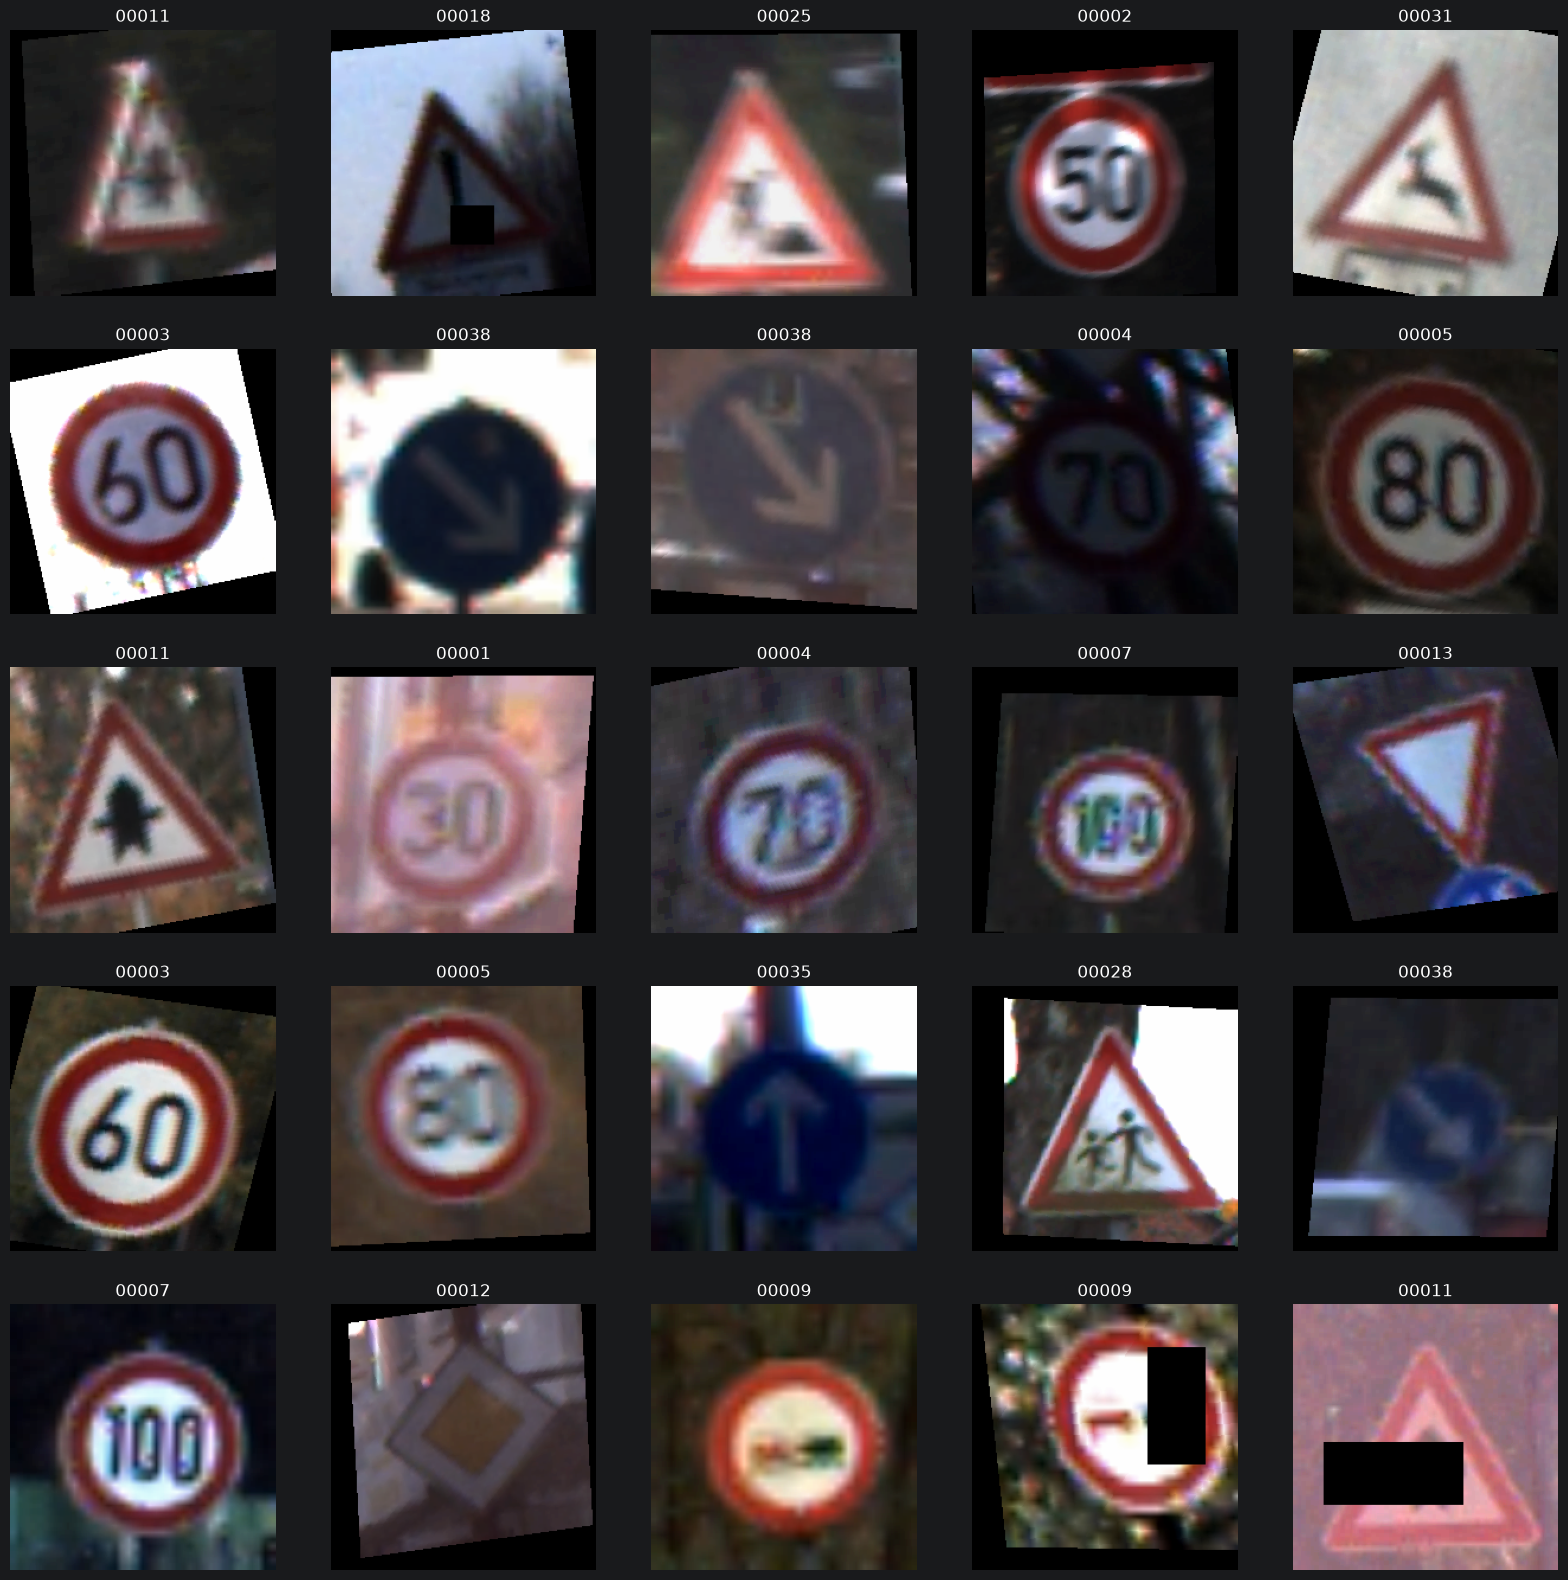

In [17]:
classes = trainset.classes

plot_images(batch[0], batch[1], classes)

## model

In [18]:
pip install timm

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [19]:
pip install einops

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [20]:
from LNL import LNL_Ti as small

D:\Projects\MachineLearning\Locality-iN-Locality\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
D:\Projects\MachineLearning\Locality-iN-Locality\.venv\Lib\site-packages\timm\models\helpers.py:7: FutureWarning: Importing from timm.models.helpers is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)
D:\Projects\MachineLearning\Locality-iN-Locality\.venv\Lib\site-packages\timm\models\layers\__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
D:\Projects\MachineLearning\Locality-iN-Locality\.venv\Lib\site-packages\timm\models\registry.py:4: FutureWarning:

In [21]:
model = small(pretrained=False, img_size=224, num_classes=43)

In [22]:
model.head

Linear(in_features=192, out_features=43, bias=True)

In [29]:
from pathlib import Path
import sys, torch
print(sys.executable)
print(torch.__file__)
print(torch.__version__, "cuda_available:", torch.cuda.is_available())

D:\Projects\MachineLearning\Locality-iN-Locality\.venv\Scripts\python.exe
D:\Projects\MachineLearning\Locality-iN-Locality\.venv\Lib\site-packages\torch\__init__.py
2.13.0+cu126 cuda_available: True


In [30]:
class NormalizedModel(torch.nn.Module):
    def __init__(self, model, mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5)):
        super().__init__()
        self.model = model
        self.register_buffer("mean", torch.tensor(mean).view(1, 3, 1, 1))
        self.register_buffer("std", torch.tensor(std).view(1, 3, 1, 1))

    def forward(self, x, *a, **kw):
        return self.model((x - self.mean) / self.std, *a, **kw)


In [31]:
eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

test_dir = './data/GTSRB/test'
testset = torchvision.datasets.ImageFolder(root=test_dir, transform=eval_transform)
test_loader = torch.utils.data.DataLoader(dataset=testset, batch_size=32, shuffle=False, num_workers=0)

In [32]:
model = small(pretrained=False, img_size=224, num_classes=43)

In [39]:
ckpt_path = Path('checkpoints/LNL_Ti_224_best.pt')
ckpt = torch.load(ckpt_path, map_location='cpu', weights_only=False)

USE_EMA = True
if USE_EMA and ckpt.get('ema') is not None:
    model.load_state_dict(ckpt['ema']); which = 'ema'
else:
    model.load_state_dict(ckpt['model']); which = 'raw'

model = NormalizedModel(model)
model = model.cuda()


In [40]:
print(f"Loaded checkpoint: {ckpt_path} (epoch {ckpt.get('epoch', '?')})")
print(f"  weights used     : {which}")
print(f"  recorded raw acc : {ckpt.get('acc', float('nan')):.2f}%")
print(f"  recorded ema acc : {ckpt.get('ema_acc', float('nan')):.2f}%")

Loaded checkpoint: checkpoints\LNL_Ti_224_best.pt (epoch 6)
  weights used     : ema
  recorded raw acc : 98.72%
  recorded ema acc : 99.50%


In [ ]:
# model.head = torch.nn.Linear(in_features=192, out_features=43, bias=True)

In [ ]:
# model = model.cuda()

## Train Locality-iN-Locality

In [35]:
# Master switch. Left False so that "Run All" reproduces the checkpoint's
# accuracy instead of spending hours degrading it.
TRAIN = False

# Fine-tune settings, mirroring run_finetune.sh (which warm-started from this
# same checkpoint). Low LR: the model is already converged, so a large LR would
# just knock it out of the basin the EMA weights sit in.
num_epochs      = 10
lr              = 5e-5      # from-scratch used 5e-4
min_lr          = 1e-6
warmup_epochs   = 1
weight_decay    = 0.05
label_smoothing = 0.1
clip_grad       = 1.0
ema_decay       = 0.9998
use_amp         = torch.cuda.is_available()

In [37]:
import math
from copy import deepcopy


class ModelEMA:
    """Exponential moving average of weights:  theta_ema <- d*theta_ema + (1-d)*theta

    This is the single largest contributor to the checkpoint's accuracy. Heavy
    augmentation makes the AdamW iterate bounce around the loss basin; the
    running average sits nearer its centre. Measured on this run: at epoch 73
    the raw weights scored 99.45% and the EMA 99.85%.
    """
    def __init__(self, model, decay):
        self.ema = deepcopy(model).eval()
        for p in self.ema.parameters():
            p.requires_grad_(False)
        self.decay = decay

    @torch.no_grad()
    def update(self, model, step):
        d = min(self.decay, (1 + step) / (10 + step))   # ramp in, forget bad early weights
        msd = model.state_dict()
        for k, v in self.ema.state_dict().items():
            if v.dtype.is_floating_point:
                v.mul_(d).add_(msd[k].detach(), alpha=1 - d)
            else:
                v.copy_(msd[k])


def param_groups(model, weight_decay):
    """No weight decay on biases / LayerNorm gains -- decaying them measurably
    hurts transformers."""
    decay, no_decay = [], []
    for n, p in model.named_parameters():
        if not p.requires_grad:
            continue
        (no_decay if p.ndim <= 1 or n.endswith('.bias') else decay).append(p)
    return [{'params': decay, 'weight_decay': weight_decay},
            {'params': no_decay, 'weight_decay': 0.0}]


# Label smoothing: the target for the true class becomes 1-e+e/K instead of 1,
# which stops the logit gap running away.
criterion = nn.CrossEntropyLoss(label_smoothing=label_smoothing)

optimizer = optim.AdamW(param_groups(model, weight_decay), lr=lr, betas=(0.9, 0.999), eps=1e-8)

# Linear warmup then cosine decay, stepped PER BATCH (not per epoch).
steps_per_epoch = max(1, len(trainset) // batch_size)
_total = max(1, num_epochs * steps_per_epoch)
_warm  = max(1, int(warmup_epochs * steps_per_epoch))
_floor = min_lr / lr

def _lr_fn(step):
    if step < _warm:
        return (step + 1) / _warm
    p = min(1.0, (step - _warm) / max(1, _total - _warm))
    return _floor + (1 - _floor) * 0.5 * (1 + math.cos(math.pi * p))

scheduler = optim.lr_scheduler.LambdaLR(optimizer, _lr_fn)
scaler    = torch.amp.GradScaler('cuda', enabled=use_amp)
ema       = ModelEMA(model, ema_decay)

print(f"optimiser : AdamW lr={lr} wd={weight_decay} ls={label_smoothing}")
print(f"schedule  : {warmup_epochs}ep warmup + cosine -> {min_lr}, {steps_per_epoch} steps/epoch")
print(f"amp={use_amp}  clip_grad={clip_grad}  ema_decay={ema_decay}")
print("\nOriginal recipe was: SGD(lr=0.007, momentum=0.9) + StepLR(step_size=30) over 5 epochs")
print("-> the LR step never fires in 5 epochs, so that was a constant LR with no warmup,")
print("   no label smoothing, no EMA and no augmentation.")

optimiser : AdamW lr=5e-05 wd=0.05 ls=0.1
schedule  : 1ep warmup + cosine -> 1e-06, 1225 steps/epoch
amp=True  clip_grad=1.0  ema_decay=0.9998

Original recipe was: SGD(lr=0.007, momentum=0.9) + StepLR(step_size=30) over 5 epochs
-> the LR step never fires in 5 epochs, so that was a constant LR with no warmup,
   no label smoothing, no EMA and no augmentation.


In [38]:
import time
import copy


@torch.no_grad()
def quick_eval(net):
    net.eval()
    correct = total = 0
    for images, labels in test_loader:
        images, labels = images.cuda(), labels.cuda()
        with torch.autocast('cuda', dtype=torch.float16, enabled=use_amp):
            pred = net(images).argmax(1)
        correct += (pred == labels).sum().item()
        total += labels.size(0)
    return 100.0 * correct / max(total, 1)


if not TRAIN:
    print("TRAIN is False -- skipping. `model` keeps the checkpoint's weights.")
    print("Set TRAIN = True above to run the fine-tune.")
else:
    # Snapshot the loaded weights so a fine-tune that fails to improve cannot
    # cost you the checkpoint you started from.
    baseline_acc   = quick_eval(model)
    baseline_state = copy.deepcopy(model.state_dict())
    best_acc, best_state, global_step = baseline_acc, baseline_state, 0
    print(f"baseline (loaded checkpoint): {baseline_acc:.2f}%\n")

    for epoch in range(num_epochs):
        model.train()
        t0, seen, running = time.time(), 0, 0.0
        total_batch = len(trainset) // batch_size

        for i, (batch_images, batch_labels) in enumerate(train_loader):
            X = batch_images.cuda(non_blocking=True)
            Y = batch_labels.cuda(non_blocking=True)

            with torch.autocast('cuda', dtype=torch.float16, enabled=use_amp):
                pre  = model(X)
                cost = criterion(pre, Y)

            optimizer.zero_grad(set_to_none=True)
            scaler.scale(cost).backward()
            if clip_grad > 0:
                scaler.unscale_(optimizer)          # gradients back to true scale
                nn.utils.clip_grad_norm_(model.parameters(), clip_grad)
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()                        # per-step cosine
            global_step += 1
            ema.update(model, global_step)

            seen    += X.size(0)
            running += cost.item() * X.size(0)
            if (i + 1) % 200 == 0:
                print('Epoch [%d/%d], lter [%d/%d], Loss: %.6f, lr %.2e'
                      % (epoch + 1, num_epochs, i + 1, total_batch,
                         running / seen, scheduler.get_last_lr()[0]))

        # Score raw AND EMA weights -- on this run the EMA branch is the one
        # that wins, which is the whole point of keeping it.
        raw_acc = quick_eval(model)
        ema_acc = quick_eval(ema.ema)
        flag = ''
        if max(raw_acc, ema_acc) > best_acc:
            best_acc  = max(raw_acc, ema_acc)
            best_state = copy.deepcopy((model if raw_acc >= ema_acc else ema.ema).state_dict())
            flag = '  *best*'
        print('epoch %d/%d: loss %.4f  raw %.2f%%  ema %.2f%%  best %.2f%%  (%.1fm)%s'
              % (epoch + 1, num_epochs, running / seen, raw_acc, ema_acc, best_acc,
                 (time.time() - t0) / 60, flag))

    model.load_state_dict(best_state)
    print(f"\nrestored best weights: {best_acc:.2f}%  (baseline was {baseline_acc:.2f}%)")
    if best_acc <= baseline_acc:
        print("fine-tune did not improve on the loaded checkpoint -- expected; "
              "see logs/train_224_finetune.log for the same outcome over 40 epochs.")

TRAIN is False -- skipping. `model` keeps the checkpoint's weights.
Set TRAIN = True above to run the fine-tune.


## Test

In [41]:
model.eval()
correct = 0
total = 0

for images, labels in test_loader:
    
    images = images.cuda()
    outputs = model(images)
    
    _, predicted = torch.max(outputs.data, 1)
    
    total += labels.size(0)
    correct += (predicted == labels.cuda()).sum()
    
print('Standard accuracy: %.2f %%' % (100 * float(correct) / total))

Standard accuracy: 99.50 %


## FGSM attack

In [43]:
model.eval()

correct = 0
total = 0

atk = FGSM(model, eps=0.01)

for images, labels in test_loader:
    
    images = atk(images, labels).cuda()
    outputs = model(images)
    
    _, predicted = torch.max(outputs.data, 1)
    
    total += labels.size(0)
    correct += (predicted == labels.cuda()).sum()
    
print('Robust accuracy: %.2f %%' % (100 * float(correct) / total))

Robust accuracy: 91.24 %


## PGD attack

In [44]:
model.eval()

correct = 0
total = 0

atk = PGD(model, eps=0.01, alpha=2/255, steps=5, random_start=False)

for images, labels in test_loader:
    
    images = atk(images, labels).cuda()
    outputs = model(images)
    
    _, predicted = torch.max(outputs.data, 1)
    
    total += labels.size(0)
    correct += (predicted == labels.cuda()).sum()
    
print('Robust accuracy: %.2f %%' % (100 * float(correct) / total))

Robust accuracy: 67.18 %


## train LNL-MoEx

In [ ]:
from LNL_MoEx import LNL_MoEx_Ti as small
model = small(pretrained=False)
model.head = torch.nn.Linear(in_features=192, out_features=43, bias=True)

In [ ]:
model = model.cuda()

In [ ]:
import time
# time.clock_gettime()

In [ ]:
num_epochs = 5
moex_lam = .9
moex_prob = .7

In [ ]:
loss = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.007, momentum=0.9)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=30, gamma=0.1)

In [ ]:
for epoch in range(num_epochs):

    total_batch = len(trainset) // batch_size
    
    for i, (input, target) in enumerate(train_loader):
        input = input.cuda()
        target = target.cuda()

        prob = torch.rand(1).item()
        if prob < moex_prob:
            swap_index = torch.randperm(input.size(0), device=input.device)
            with torch.no_grad():
                target_a = target
                target_b = target[swap_index]
            output = model(input, swap_index=swap_index, moex_norm='pono', moex_epsilon=1e-5,
                           moex_layer='stem', moex_positive_only=False)
            lam = moex_lam
            cost = loss(output, target_a) * lam + loss(output, target_b) * (1. - lam)
        else:
            # compute output
            output = model(input)
            # if args.prof >= 0: torch.cuda.nvtx.range_pop()
            cost = loss(output, target)

        # compute gradient and do SGD step

        optimizer.zero_grad()
        cost.backward()
        optimizer.step()

        if (i+1) % 200 == 0:
            print('Epoch [%d/%d], lter [%d/%d], Loss: %.6f'
                 %(epoch+1, num_epochs, i+1, total_batch, cost.item()))

## Number of Parameters

In [ ]:
pip install ptflops

In [ ]:
pip install --upgrade git+https://github.com/sovrasov/flops-counter.pytorch.git

In [ ]:
import torch
from ptflops import get_model_complexity_info

with torch.cuda.device(0):
  net = model
  macs, params = get_model_complexity_info(net, (3, 224, 224), as_strings=True,
                                           print_per_layer_stat=True, verbose=True)
  print('{:<30}  {:<8}'.format('Computational complexity: ', macs))
  print('{:<30}  {:<8}'.format('Number of parameters: ', params))
